# Biggest Polities: Direct HYDE × Cliopatria Computation

Overlay Cliopatria polity polygons directly on the HYDE 3.4 population grid
to compute population under each polity at each time step. No sampling needed.

For each HYDE time step (127 steps from 10,000 BCE to 2024 CE):
1. Find all Cliopatria polities active at that year
2. Rasterize each polygon onto the HYDE 2160×4320 grid
3. Sum population within each polygon

This gives population under each polity at each time step, from which we can
compute total person-years, total births, and population-over-time graphs.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import h5py
from rasterio.features import geometry_mask
from rasterio.transform import from_bounds
from shapely.geometry import mapping
from tqdm import tqdm
import matplotlib.pyplot as plt

## 1. Load data

In [2]:
# Load HYDE population grid
ds = xr.open_dataset('../Raw_Data/HYDE34/NetCDF/population.nc', decode_times=False)
pop_all = ds['population']  # shape (127, 2160, 4320)
lats = pop_all.coords['lat'].values
lons = pop_all.coords['lon'].values

# Convert time to years (same formula as person.py)
hyde_years = (ds['time'].values // 365).astype(int) + 1

# Extend to 2025 by duplicating the 2024 grid (HYDE ends at 2024)
hyde_years = np.append(hyde_years, 2025)
print(f'HYDE: {len(hyde_years)} time steps, {hyde_years[0]} to {hyde_years[-1]} (2025 extrapolated from 2024)')
print(f'Grid: {pop_all.shape[1]}×{pop_all.shape[2]}')

# Load births grid (128 steps; first 127 align with population, 128th is 2025)
with h5py.File('../Processed_Data/births_array.h5', 'r') as f:
    births_all = f['data'][:128]
print(f'Births: {births_all.shape}')

# Rasterization transform (HYDE grid bounds)
TRANSFORM = from_bounds(
    lons.min() - 0.0833/2, lats.min() - 0.0833/2,
    lons.max() + 0.0833/2, lats.max() + 0.0833/2,
    4320, 2160
)

# Load land/sea mask and compute coastal cells
from scipy.ndimage import binary_dilation
landlake = np.loadtxt('../Raw_Data/HYDE34/general/landlake.asc', skiprows=6)
land = (landlake == 1)
sea = (landlake == -9999)
coastal = land & binary_dilation(sea)
print(f'Coastal cells: {coastal.sum():,}, interior land: {(land & ~coastal).sum():,}')

# Load Cliopatria
clio_raw = gpd.read_file('cliopatria_polities_only.geojson')
clio = clio_raw.copy()
clio['is_container'] = clio['Name'].str.startswith('(')

# Extend polities ending at 2024 to 2025 (they obviously still exist)
clio.loc[clio['ToYear'] == 2024, 'ToYear'] = 2025

n_polity = (~clio['is_container']).sum()
n_container = clio['is_container'].sum()
print(f'Cliopatria: {len(clio):,} total records ({n_polity:,} polities, {n_container:,} containers), {clio["Name"].nunique()} unique names')

HYDE: 128 time steps, -10000 to 2025 (2025 extrapolated from 2024)
Grid: 2160×4320
Births: (128, 2160, 4320)
Coastal cells: 65,196, interior land: 2,150,633


/opt/anaconda3/lib/python3.11/site-packages/pyogrio/core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


Cliopatria: 15,690 total records (12,987 polities, 2,703 containers), 1618 unique names


/opt/anaconda3/lib/python3.11/site-packages/geopandas/array.py:348: UserWarning: Cannot set the CRS, falling back to None. The CRS support requires the 'pyproj' package, but it is not installed or does not import correctly. The functions depending on CRS will raise an error or may produce unexpected results.
  self.crs = crs
/opt/anaconda3/lib/python3.11/site-packages/geopandas/geodataframe.py:464: UserWarning: Cannot set the CRS, falling back to None. The CRS support requires the 'pyproj' package, but it is not installed or does not import correctly. The functions depending on CRS will raise an error or may produce unexpected results.
  level.crs = crs


## 2. Compute annual population and births for each Cliopatria polity

For each Cliopatria record (polygon with FromYear–ToYear):
1. Rasterize the polygon onto the HYDE grid (once per record)
2. At each HYDE time step within [FromYear, ToYear], sum population and births within the mask
3. Log-linear interpolate between HYDE steps to get annual values
4. When multiple records exist for the same polity name (different time periods or boundary changes), stitch them together

This gives an annual time series of population and births for every polity.

In [3]:
# For each Cliopatria record: rasterize polygon, sum HYDE population AND births at
# relevant time steps, then log-linear interpolate to get annual values.

# Preload all HYDE grids into memory
print('Loading all HYDE grids...')
pop_grids = {}
birth_grids = {}
for ti, year in enumerate(hyde_years):
    if ti < len(pop_all.time):
        pop_grids[year] = pop_all.isel(time=ti).values
    else:
        pop_grids[year] = pop_grids[hyde_years[ti - 1]]
    if ti < len(births_all):
        birth_grids[year] = births_all[ti]
    else:
        birth_grids[year] = birth_grids[hyde_years[ti - 1]]

# World totals at each HYDE step
world_pop_hyde = {year: np.nansum(grid) for year, grid in pop_grids.items()}
world_births_hyde = {year: np.nansum(grid) for year, grid in birth_grids.items()}

def log_interp(hyde_yrs, hyde_vals, from_year, to_year):
    """Log-linear interpolate HYDE values to annual series for [from_year, to_year]."""
    hyde_vals_safe = np.where(hyde_vals > 0, hyde_vals, 1.0)
    all_zero = hyde_vals <= 0
    log_vals = np.log(hyde_vals_safe)
    exact = dict(zip(hyde_yrs.tolist(), hyde_vals.tolist()))
    
    annual = {}
    for year in range(from_year, to_year + 1):
        if year in exact:
            annual[year] = exact[year]
        elif year < hyde_yrs[0] or year > hyde_yrs[-1]:
            continue
        else:
            idx = np.searchsorted(hyde_yrs, year, side='right') - 1
            y0, y1 = hyde_yrs[idx], hyde_yrs[idx + 1]
            t = (year - y0) / (y1 - y0)
            if all_zero[idx] and all_zero[idx + 1]:
                annual[year] = 0.0
            else:
                annual[year] = np.exp(log_vals[idx] * (1 - t) + log_vals[idx + 1] * t)
    return annual

# Process each Cliopatria record
print(f'Processing {len(clio):,} Cliopatria records...')
record_results = []

all_hyde_sorted = sorted(hyde_years)

for _, row in tqdm(clio.iterrows(), total=len(clio), desc='Rasterizing'):
    name = row['Name']
    from_year = int(row['FromYear'])
    to_year = int(row['ToYear'])
    
    # Single rasterization with all_touched to capture coastal cells
    try:
        mask = geometry_mask([mapping(row.geometry)], out_shape=(2160, 4320),
                            transform=TRANSFORM, invert=True, all_touched=True)
    except Exception:
        continue
    
    if not mask.any():
        continue
    
    # Find HYDE years for interpolation
    active_hyde = [y for y in hyde_years if from_year <= y <= to_year]
    idx_before = np.searchsorted(all_hyde_sorted, from_year) - 1
    idx_after = np.searchsorted(all_hyde_sorted, to_year, side='right')
    if idx_before >= 0:
        active_hyde = [all_hyde_sorted[idx_before]] + active_hyde
    if idx_after < len(all_hyde_sorted):
        active_hyde = active_hyde + [all_hyde_sorted[idx_after]]
    active_hyde = sorted(set(active_hyde))
    
    if len(active_hyde) == 0:
        continue
    
    # Sum population and births within mask at each HYDE year
    hyde_pops = np.array([np.nansum(pop_grids[y][mask]) for y in active_hyde])
    hyde_births = np.array([np.nansum(birth_grids[y][mask]) for y in active_hyde])
    active_hyde = np.array(active_hyde)
    
    # Log-linear interpolate to every year in [from_year, to_year]
    pop_annual = log_interp(active_hyde, hyde_pops, from_year, to_year)
    births_annual = log_interp(active_hyde, hyde_births, from_year, to_year)
    
    for year in range(from_year, to_year + 1):
        pop = pop_annual.get(year)
        births = births_annual.get(year)
        if pop is not None:
            record_results.append((name, year, pop, births or 0.0))

print(f'{len(record_results):,} annual polity-year records')

df_annual = pd.DataFrame(record_results, columns=['polity', 'year', 'population', 'births'])
print(f'{df_annual["polity"].nunique()} polities')

# World annual series
world_pop_annual = log_interp(
    np.array(sorted(world_pop_hyde.keys())),
    np.array([world_pop_hyde[y] for y in sorted(world_pop_hyde.keys())]),
    int(hyde_years[0]), int(hyde_years[-1])
)
world_births_annual = log_interp(
    np.array(sorted(world_births_hyde.keys())),
    np.array([world_births_hyde[y] for y in sorted(world_births_hyde.keys())]),
    int(hyde_years[0]), int(hyde_years[-1])
)

Loading all HYDE grids...
Processing 15,690 Cliopatria records...


Rasterizing: 100%|████████████████████████| 15690/15690 [04:27<00:00, 58.76it/s]


260,847 annual polity-year records
1618 polities


## 3. Rankings: total person-years and total births by polity

In [12]:
# Filter out bad data: HRE after 1259 (gap until Minor States, rump 1619-1621)
df_annual = df_annual[~((df_annual['polity'] == 'Holy Roman Empire') & (df_annual['year'] > 1259))]

# Person-years, total births, and max population by polity
polity_py = df_annual.groupby('polity')['population'].sum().sort_values(ascending=False)
polity_births = df_annual.groupby('polity')['births'].sum().sort_values(ascending=False)
polity_max_pop = df_annual.groupby('polity')['population'].max().sort_values(ascending=False)

world_py = sum(world_pop_annual.values())
world_births = sum(world_births_annual.values())

from math import log10, floor
def sig2(x):
    if x == 0: return '0'
    d = -floor(log10(abs(x))) + 1
    r = round(x, d)
    if d <= 0: return f'{int(r):,}'
    return f'{r:,.{d}f}'

# Identify containers
container_names = set(clio[clio['is_container']]['Name'].unique())

print(f'Total person-years (world): {world_py/1e9:.0f} billion')
print(f'Total births (world): {world_births/1e9:.1f} billion')

def print_ranking(py_series, births_series, max_pop_series, title, name_filter, n=50):
    filtered = [(name, py) for name, py in py_series.items() if name_filter(name)]
    print(f'\n{"="*95}')
    print(f'{title}')
    print(f'{"="*95}')
    print(f'{"Rank":<5} {"Polity":<45} {"Pers-yrs (B)":>12} {"Births (M)":>10} {"Max pop (M)":>11}')
    print('-' * 95)
    for i, (name, py) in enumerate(filtered[:n], 1):
        births = births_series.get(name, 0)
        max_pop = max_pop_series.get(name, 0)
        print(f'{i:<5} {name:<45} {sig2(py/1e9):>12} {sig2(births/1e6):>10} {sig2(max_pop/1e6):>11}')

print_ranking(polity_py, polity_births, polity_max_pop, 'POLITIES (most specific)',
              lambda n: n not in container_names)
print_ranking(polity_py, polity_births, polity_max_pop, 'CONTAINERS (broadest umbrella)',
              lambda n: n in container_names, n=20)

Total person-years (world): 1697 billion
Total births (world): 62.5 billion

POLITIES (most specific)
Rank  Polity                                        Pers-yrs (B) Births (M) Max pop (M)
-----------------------------------------------------------------------------------------------
1     People's Republic of China                              79      1,600       1,400
2     Republic of India                                       67      1,900       1,500
3     Qing Dynasty                                            65      2,500         430
4     British Raj                                             30      1,400         450
5     United States of America                                30        620         360
6     Mughal Empire                                           23        970         180
7     Ming Dynasty                                            22        900          87
8     Roman Empire                                            17        710          45
9     Unio

## 4. Population over time: top 10 polities

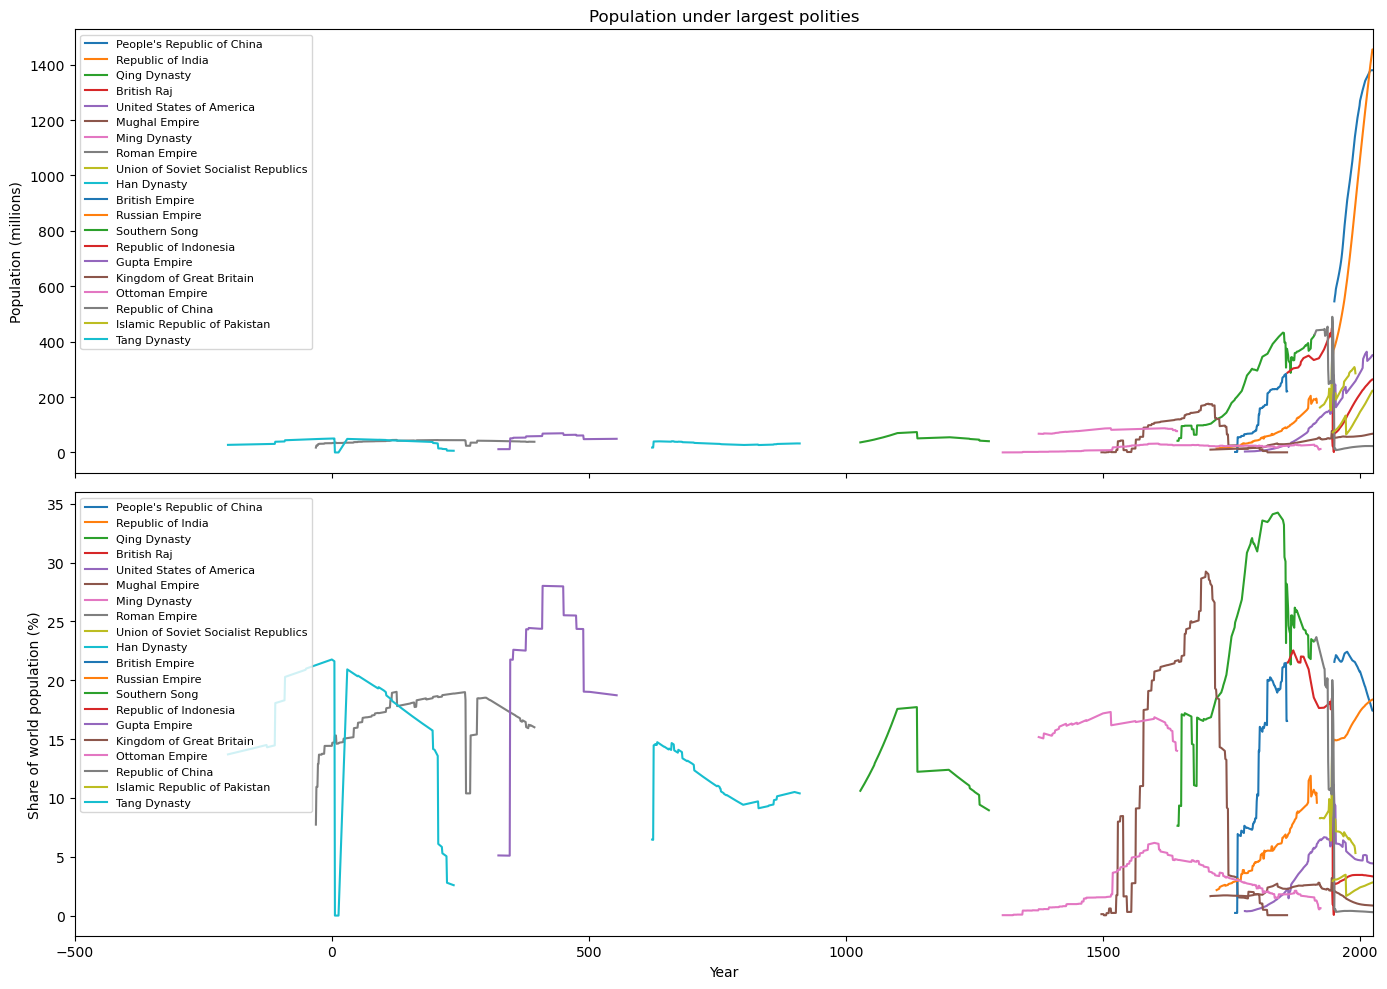

In [5]:
# Get top 10 non-container polities by person-years
top10 = [name for name, _ in polity_py.items() if name not in container_names][:20]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for polity in top10:
    pdata = df_annual[df_annual['polity'] == polity].set_index('year')['population'].sort_index()
    ax1.plot(pdata.index, pdata.values / 1e6, label=polity, linewidth=1.5)

ax1.set_ylabel('Population (millions)')
ax1.set_title('Population under largest polities')
ax1.legend(fontsize=8, loc='upper left')
ax1.set_xlim(-500, 2026)

# Share of world population
world_series = pd.Series(world_pop_annual).sort_index()

for polity in top10:
    pdata = df_annual[df_annual['polity'] == polity].set_index('year')['population'].sort_index()
    common_years = pdata.index.intersection(world_series.index)
    share = 100 * pdata.loc[common_years] / world_series.loc[common_years]
    ax2.plot(share.index, share.values, label=polity, linewidth=1.5)

ax2.set_ylabel('Share of world population (%)')
ax2.set_xlabel('Year')
ax2.legend(fontsize=8, loc='upper left')
ax2.set_xlim(-500, 2026)

plt.tight_layout()
plt.show()

## 5. Blog post cleanup

Merge name variants, rename confusing names, exclude non-polities, split ambiguous entries.

In [13]:
POLITY_MERGES = {
    'Eastern Roman Empire': 'Byzantine Empire',
    'Kuomintang': 'Republic of China (mainland)',
    'Empire of China': 'Republic of China (mainland)',
    'Union of Myanmar': 'Myanmar',
    'Brazilian Republic': 'Brazil',
    'Federated Republic of Brazil': 'Brazil',
    'Republic of Brazil': 'Brazil',
    'Unitary State of Brazil': 'Brazil',
    'Federal Republic of Germany': 'West/Reunified Germany',
    'Federated Republic of Germany': 'West/Reunified Germany',
    'United Arab Republic': 'Egypt',
    'Arab Republic of Egypt': 'Egypt',
    'Mali Federation': 'Mali',
    'Iragi Republic': 'Iraq',
    'Republic of Iraq': 'Iraq',
}

POLITY_RENAMES = {
    'British Empire': 'East India Company',
    'Bourbon Kingdom of France': 'Restoration France',
    'Napoleonic Batavia Republic': 'Dutch Gold Coast',
}

POLITY_EXCLUDE = {
    'Holy Roman Empire Minor States',
}

def fmt_year(y):
    return f'{-y} BCE' if y < 0 else f'{y} CE'

def clean_polity_name(name, year):
    if name in POLITY_EXCLUDE:
        return None
    if name in POLITY_MERGES:
        name = POLITY_MERGES[name]
    if name in POLITY_RENAMES:
        name = POLITY_RENAMES[name]
    if name == 'Republic of China':
        return 'Republic of China (Taiwan)' if year >= 1950 else 'Republic of China (mainland)'
    if name == 'Burma':
        return 'Burma (Konbaung)' if year < 1948 else 'Myanmar'
    if name == 'Denmark-Norway' and year >= 1814:
        return 'Denmark'
    if name == 'Kingdom of Italy':
        return 'Kingdom of Italy (Lombard/Carolingian)' if year < 1000 else 'Kingdom of Italy (modern)'
    # HRE: only valid until 1259; after that Cliopatria uses 'Minor States' (excluded)
    # and the 1619-1621 rump record is not meaningful
    if name == 'Holy Roman Empire' and year > 1259:
        return None
    return name

# Apply cleaning to df_annual (non-containers only)
df_clean = df_annual[~df_annual['polity'].str.startswith('(')].copy()
df_clean['clean_name'] = df_clean.apply(lambda r: clean_polity_name(r['polity'], r['year']), axis=1)
df_clean = df_clean[df_clean['clean_name'].notna()]

# Aggregate
clean_py = df_clean.groupby('clean_name')['population'].sum().sort_values(ascending=False)
clean_births = df_clean.groupby('clean_name')['births'].sum().sort_values(ascending=False)
clean_max_pop = df_clean.groupby('clean_name')['population'].max().sort_values(ascending=False)
clean_years = df_clean.groupby('clean_name')['year'].agg(['min', 'max'])

print(f'{"Rank":<5} {"Polity":<45} {"Years":<20} {"Pers-yrs (B)":>12} {"Births (M)":>10} {"Max pop (M)":>11}')
print('-' * 108)
for i, (name, births) in enumerate(clean_births.head(1000).items(), 1):
    py = clean_py.get(name, 0)
    max_pop = clean_max_pop.get(name, 0)
    yrs = clean_years.loc[name]
    yr_str = f'{fmt_year(int(yrs["min"]))}–{fmt_year(int(yrs["max"]))}'
    print(f'{i:<5} {name:<45} {yr_str:<20} {sig2(py/1e9):>12} {sig2(births/1e6):>10} {sig2(max_pop/1e6):>11}')

print(f'\n{len(clean_py)} polities after cleanup')

Rank  Polity                                        Years                Pers-yrs (B) Births (M) Max pop (M)
------------------------------------------------------------------------------------------------------------
1     Qing Dynasty                                  1645 CE–1911 CE                65      2,500         430
2     Republic of India                             1947 CE–2025 CE                67      1,900       1,500
3     People's Republic of China                    1950 CE–2025 CE                79      1,600       1,400
4     British Raj                                   1859 CE–1947 CE                30      1,400         450
5     Mughal Empire                                 1497 CE–1858 CE                23        970         180
6     Ming Dynasty                                  1375 CE–1644 CE                22        900          87
7     Roman Empire                                  31 BCE–394 CE                  17        710          45
8     Russian Empir

## 6. Super-polity groups

Broader entities: manually defined groups + Cliopatria containers.

In [7]:
SUPER_POLITIES = {
    'Imperial China (canonical succession)': [
        'Qin Dynasty', 'Han Dynasty', 'Xin Dynasty',
        'Western Jin',
        'Sui Dynasty', 'Tang Dynasty',
        'Northern Song', 'Southern Song',
        'Yuan Dynasty', 'Ming Dynasty', 'Qing Dynasty',
    ],
    'Russia (Muscovy onward)': [
        'Grand Principality of Moscow', 'Tsardom of Russia', 'Russian Empire',
        'Russian Republic',
        'Union of Soviet Socialist Republics', 'Russian Federation',
    ],
    'Caliphate (Rashidun–Abbasid)': [
        'Rashidun Caliphate', 'Umayyad Caliphate', 'Abbasid Caliphate',
    ],
    'Roman state': [
        'Roman Republic', 'Roman Empire', 'Western Roman Empire',
        'Eastern Roman Empire', 'Byzantine Empire',
        'Nicaean Empire', 'Empire of Trebizond',
    ],
    'Genghisid domains': [
        'Mongol Empire',
        'Yuan Dynasty', 'Northern Yuan',
        'Golden Horde', 'Chagatai Khanate', 'Eastern Chagatai Khanate', 'Ilkhanate',
        'Crimean Khanate', 'Kazakh Khanate', 'Khanate of Kazan',
        'Astrakhan Khanate', 'Khanate of Sibir', 'Qasim Khanate',
        'Khanate of Bukhara', 'Khanate of Khiva', 'Mongol Khanate',
    ],
    'Habsburg domains': [
        'House of Habsburg', 'Habsburg Monarchy',
        'Austrian Empire', 'Austria-Hungary',
        ('Kingdom of Bohemia', 1526, 9999),
        ('Kingdom of Hungary', 1526, 1918),
        'Principality of Transylvania',
        ('Kingdom of Spain', 1516, 1700),
        ('Spanish Empire', 1516, 1700),
        'Iberian Union', 'Pro-Habsburg Spain',
    ],
    'Bourbon domains': [
        ('Kingdom of France', 1589, 1792),
        'Bourbon Kingdom of France',
        ('New France', 1589, 1792),
        ('French India', 1589, 1792),
        ('Kingdom of Spain', 1700, 9999),
        ('Spanish Empire', 1700, 1879),
        'Kingdom of the Two Sicilies',
        ('Kingdom of Naples (Napoleonic)', 1734, 1806),
        'Duchy of Parma and Piacenza',
    ],
    'Japan (under the Emperor)': [
        'Yamato', 'Kamakura Shogunate', 'Ashikaga Shogunate',
        'Tokugawa Shogunate', 'Empire of Japan', 'Japan',
    ],
    'British Empire (~1600–1997)': [
        # Metropole from 1600
        ('Kingdom of England', 1600, 9999),
        'Kingdom of Great Britain',
        # Colonial
        'British Colonial Empire', 'British Empire',  # EIC India
        'British Raj', 'British Africa', 'British Cape Colony',
        'British Ceylon', 'British East Africa', 'British Overseas Territories',
    ],
    'French Empire (~1600–1960)': [
        # Metropole from 1600
        ('Kingdom of France', 1600, 1791),
        'French First Republic', 'First French Empire',
        'Bourbon Kingdom of France', 'French Second Republic',
        'Second French Empire', 'French Third Republic',
        'Vichy France', 'Free French', 'French Fourth Republic',
        # Colonial
        'New France', 'French Africa', 'French Algiers',
        'French Equatorial Africa', 'French India', 'French Indochina',
        'French Colonial Vietnam', 'French Mandate for Syria and Lebanon',
        'French Louisiana', 'French Colony of Guiana', 'France Antarctique',
    ],
    'Spanish Empire (1516–1898)': [
        'Kingdom of Spain',
        ('Spanish Empire', None, 1898),
        'Iberian Union',
    ],
    'Portuguese Empire (~1500–1975)': [
        ('Kingdom of Portugal', 1500, 9999),
        'Portuguese Republic',
        ('Portugal', None, 1975),
        'Portuguese Empire', 'Portuguese Africa', 'Portuguese Colonies',
        'Portuguese Ceylon',
        ('Empire of Brazil', None, 1822),  # Brazil only while Portuguese colony
    ],
    'Dutch Empire (~1600–1949)': [
        'Dutch Republic', 'Batavian Republic',
        'Sovereign Principality of the United Netherlands',
        ('Netherlands', None, 1949),
        'Dutch East Indies', 'Dutch Cape Coast', 'Dutch Ceylon',
        'New Netherland', 'Napoleonic Batavia Republic',
        ('Netherlands Antilles', None, 1949),
    ],
    'Italian Empire (1861–1945)': [
        ('Kingdom of Italy', 1861, 1946),
        'Italian Africa',
    ],
    'German Empire (1871–1919)': [
        'German Empire', 'German Africa',
    ],
    'Belgian Empire': [
        'Kingdom of Belgium', 'Belgian Congo',
    ],
}

CONTAINER_GROUPS = [
    '(Delhi Sultanate)',
    '(Holy Roman Empire)',
]

def count_super_polity_direct(members, df):
    """Filter df_annual rows matching a super-polity group."""
    masks = []
    for member in members:
        if isinstance(member, tuple):
            name, start, end = member
            start = start if start is not None else -99999
            end = end if end is not None else 99999
            masks.append((df['polity'] == name) & (df['year'] >= start) & (df['year'] <= end))
        else:
            masks.append(df['polity'] == member)
    combined = masks[0]
    for m in masks[1:]:
        combined = combined | m
    return df[combined]

# Compute for all groups
group_results = []

for group_name, members in SUPER_POLITIES.items():
    sub = count_super_polity_direct(members, df_annual)
    py = sub['population'].sum()
    births = sub['births'].sum()
    max_pop = sub.groupby('year')['population'].sum().max() if len(sub) > 0 else 0
    min_year = sub['year'].min() if len(sub) > 0 else 0
    max_year = sub['year'].max() if len(sub) > 0 else 0
    group_results.append((group_name, py, births, max_pop, min_year, max_year))

for container_name in CONTAINER_GROUPS:
    sub = df_annual[df_annual['polity'] == container_name]
    py = sub['population'].sum()
    births = sub['births'].sum()
    max_pop = sub['population'].max() if len(sub) > 0 else 0
    min_year = sub['year'].min() if len(sub) > 0 else 0
    max_year = sub['year'].max() if len(sub) > 0 else 0
    group_results.append((container_name, py, births, max_pop, min_year, max_year))

group_results.sort(key=lambda x: -x[1])

print(f'{"Rank":<5} {"Super-polity":<45} {"Years":<18} {"Pers-yrs (B)":>12} {"Births (M)":>10} {"Max pop (M)":>11}')
print('-' * 105)
for i, (name, py, births, max_pop, yr_min, yr_max) in enumerate(group_results, 1):
    yr_str = f'{fmt_year(int(yr_min))}–{fmt_year(int(yr_max))}'
    print(f'{i:<5} {name:<45} {yr_str:<18} {sig2(py/1e9):>12} {sig2(births/1e6):>10} {sig2(max_pop/1e6):>11}')

Rank  Super-polity                                  Years              Pers-yrs (B) Births (M) Max pop (M)
---------------------------------------------------------------------------------------------------------
1     Imperial China (canonical succession)         218 BCE–1911 CE             140      5,600         430
2     British Empire (~1600–1997)                   1600 CE–2025 CE              65      2,600         640
3     Russia (Muscovy onward)                       1294 CE–2025 CE              37      1,200         360
4     Roman state                                   500 BCE–1474 CE              29      1,200          45
5     Japan (under the Emperor)                     540 CE–2025 CE               28        810         520
6     Genghisid domains                             1206 CE–1919 CE              16        680         120
7     French Empire (~1600–1960)                    1556 CE–1957 CE              16        520         150
8     Habsburg domains                

## 7. Metropole vs colonial populations

In [8]:
# For colonial empires, split into metropole vs colonial holdings
# Metropole dates are clipped to the empire's active period.

EMPIRE_SPLITS = {
    'British Empire (~1600–1997)': {
        'metropole': [('Kingdom of England', 1600, 1708), ('Kingdom of Great Britain', None, 1997)],
        'colonial': ['British Colonial Empire', 'British Empire', 'British Raj',
                     'British Africa', 'British Cape Colony', 'British Ceylon',
                     'British East Africa', 'British Overseas Territories'],
    },
    'French Empire (~1600–1960)': {
        'metropole': [
            ('Kingdom of France', 1600, 1791),
            'French First Republic', 'First French Empire',
            'Bourbon Kingdom of France', 'French Second Republic',
            'Second French Empire', 'French Third Republic',
            'Vichy France', 'Free French', 'French Fourth Republic',
        ],
        'colonial': [
            'New France', 'French Africa', 'French Algiers',
            'French Equatorial Africa', 'French India', 'French Indochina',
            'French Colonial Vietnam', 'French Mandate for Syria and Lebanon',
            'French Louisiana', 'French Colony of Guiana', 'France Antarctique',
        ],
    },
    'Spanish Empire (1516–1898)': {
        'metropole': [('Kingdom of Spain', None, 1898)],
        'colonial': [('Spanish Empire', None, 1898), 'Iberian Union'],
    },
    'Portuguese Empire (~1500–1975)': {
        'metropole': [('Kingdom of Portugal', 1500, 1911), ('Portuguese Republic', None, 1975),
                      ('Portugal', None, 1975), ('Estado Novo', None, 1975)],
        'colonial': ['Portuguese Empire', 'Portuguese Africa', 'Portuguese Colonies',
                     'Portuguese Ceylon', ('Empire of Brazil', None, 1822)],
        # Note: Portuguese Republic and Estado Novo include both metropole and colonies
        # in a single polygon, so the metropole/colonial split is not clean for 1911-1975.
    },
    'Dutch Empire (~1600–1949)': {
        'metropole': ['Dutch Republic', 'Batavian Republic',
                      'Sovereign Principality of the United Netherlands',
                      ('Netherlands', None, 1949)],
        'colonial': ['Dutch East Indies', 'Dutch Cape Coast', 'Dutch Ceylon',
                     'New Netherland', 'Napoleonic Batavia Republic',
                     ('Netherlands Antilles', None, 1949)],
    },
    'Italian Empire (1861–1945)': {
        'metropole': [('Kingdom of Italy', 1861, 1945)],
        'colonial': ['Italian Africa'],
    },
    'German Empire (1871–1919)': {
        'metropole': ['German Empire'],
        'colonial': ['German Africa'],
    },
    'Belgian Empire': {
        'metropole': [('Kingdom of Belgium', 1890, 1962)],
        'colonial': ['Belgian Congo'],
    },
}

def compute_split(members, df):
    sub = count_super_polity_direct(members, df)
    if len(sub) == 0:
        return 0, 0, pd.Series(dtype=float)
    py = sub['population'].sum()
    births = sub['births'].sum()
    annual_pop = sub.groupby('year')['population'].sum()
    return py, births, annual_pop

for empire_name, split in EMPIRE_SPLITS.items():
    m_py, m_births, m_annual = compute_split(split['metropole'], df_annual)
    c_py, c_births, c_annual = compute_split(split['colonial'], df_annual)
    t_py = m_py + c_py
    t_births = m_births + c_births
    
    # Peak year: max of combined population
    combined_annual = m_annual.add(c_annual, fill_value=0)
    if len(combined_annual) > 0:
        peak_year = int(combined_annual.idxmax())
        t_max = combined_annual[peak_year]
        m_at_peak = m_annual.get(peak_year, 0)
        c_at_peak = c_annual.get(peak_year, 0)
        pct_colonial_peak = 100 * c_at_peak / t_max if t_max > 0 else 0
    else:
        peak_year = t_max = m_at_peak = c_at_peak = pct_colonial_peak = 0
    
    pct_colonial_py = 100 * c_py / t_py if t_py > 0 else 0
    pct_colonial_births = 100 * c_births / t_births if t_births > 0 else 0
    
    print(f'=== {empire_name} ===')
    print(f'  {"":12} {"Pers-yrs (B)":>12} {"Births (M)":>10}')
    print(f'  {"Total":<12} {sig2(t_py/1e9):>12} {sig2(t_births/1e6):>10}')
    print(f'  {"Metropole":<12} {sig2(m_py/1e9):>12} {sig2(m_births/1e6):>10}')
    print(f'  {"Colonial":<12} {sig2(c_py/1e9):>12} {sig2(c_births/1e6):>10}')
    print(f'  {"% colonial":<12} {pct_colonial_py:>11.1f}% {pct_colonial_births:>9.1f}%')
    print(f'  Peak population: {sig2(t_max/1e6)}M in {peak_year} (metro {sig2(m_at_peak/1e6)}M + colonial {sig2(c_at_peak/1e6)}M, {pct_colonial_peak:.0f}% colonial)')
    print()

=== British Empire (~1600–1997) ===
               Pers-yrs (B) Births (M)
  Total                  63      2,600
  Metropole              10        260
  Colonial               53      2,300
  % colonial          83.9%      89.7%
  Peak population: 640M in 1945 (metro 77M + colonial 560M, 88% colonial)

=== French Empire (~1600–1960) ===
               Pers-yrs (B) Births (M)
  Total                  16        520
  Metropole              10        290
  Colonial              5.3        220
  % colonial          33.6%      43.3%
  Peak population: 150M in 1955 (metro 48M + colonial 100M, 68% colonial)

=== Spanish Empire (1516–1898) ===
               Pers-yrs (B) Births (M)
  Total                  10        410
  Metropole             5.0        190
  Colonial              5.1        220
  % colonial          50.6%      53.2%
  Peak population: 36M in 1540 (metro 20M + colonial 16M, 44% colonial)

=== Portuguese Empire (~1500–1975) ===
               Pers-yrs (B) Births (M)
  Total 

## 8. Top dynasties

A dynasty = a ruling family across all the polities they ruled simultaneously or successively.
Some dynasties ruled multiple kingdoms at once (Habsburgs), some ruled one state across
name changes (Romanovs: Tsardom → Empire → ?).

In [9]:
# Each dynasty: list of (polity_name, start, end) or just polity_name.
# Year constraints narrow to the period when that dynasty actually ruled.

DYNASTIES = {
    # === Chinese dynasties (each is its own ruling family) ===
    'Qing (Aisin-Gioro)': ['Qing Dynasty'],
    'Ming (Zhu)': ['Ming Dynasty'],
    'Han (Liu)': ['Han Dynasty'],  # 202 BCE - 220 CE
    'Tang (Li)': ['Tang Dynasty'],
    'Song (Zhao)': ['Northern Song', 'Southern Song'],
    
    # === Ottoman ===
    'Ottoman (Osman)': ['Ottoman Empire'],
    
    # === Mughal + Timurid (same dynasty: Timurid line) ===
    'Timurid (incl. Mughal)': ['Timurid Empire', 'Mughal Empire'],
    
    # === Genghisid (all Borjigin descendants) ===
    'Genghisid (Borjigin)': [
        'Mongol Empire',
        'Yuan Dynasty', 'Northern Yuan',
        'Golden Horde', 'Chagatai Khanate', 'Eastern Chagatai Khanate', 'Ilkhanate',
        'Crimean Khanate', 'Kazakh Khanate', 'Khanate of Kazan',
        'Astrakhan Khanate', 'Khanate of Sibir', 'Qasim Khanate',
        'Khanate of Bukhara', ('Khanate of Khiva', None, 1804), 'Mongol Khanate',  # Khiva: Genghisid until 1804
    ],
    
    # === Habsburg (Austrian + Spanish branches) ===
    'Habsburg': [
        'House of Habsburg', 'Habsburg Monarchy',
        'Austrian Empire', 'Austria-Hungary',
        ('Kingdom of Bohemia', 1526, 9999),
        ('Kingdom of Hungary', 1526, 1918),
        'Principality of Transylvania',
        ('Kingdom of Spain', 1516, 1700),
        ('Spanish Empire', 1516, 1700),
        'Iberian Union', 'Pro-Habsburg Spain',
    ],
    
    # === Bourbon ===
    'Bourbon': [
        ('Kingdom of France', 1589, 1792),
        'Bourbon Kingdom of France',
        ('New France', 1589, 1792),
        ('French India', 1589, 1792),
        ('Kingdom of Spain', 1700, 9999),
        ('Spanish Empire', 1700, 1879),
        'Kingdom of the Two Sicilies',
        ('Kingdom of Naples (Napoleonic)', 1734, 1806),
        'Duchy of Parma and Piacenza',
    ],
    
    # === Capetian (full dynasty: direct + Valois + Bourbon) ===
    'Capetian (all branches)': [
        ('Kingdom of France', 987, 1792),  # Direct 987-1328, Valois 1328-1589, Bourbon 1589-1792
        'Bourbon Kingdom of France',  # Restoration
        ('New France', 987, 1792),
        ('French India', 987, 1792),
        ('Kingdom of Spain', 1700, 9999),  # Spanish Bourbons
        ('Spanish Empire', 1700, 1879),
        'Kingdom of the Two Sicilies',
        ('Kingdom of Naples (Napoleonic)', 1734, 1806),
        'Duchy of Parma and Piacenza',
    ],
    
    # === Romanov ===
    'Romanov': [
        ('Tsardom of Russia', 1613, 9999),
        'Russian Empire',
    ],
    
    # === Hanover / Windsor (British, from 1714) ===
    'Hanover / Windsor': [
        ('Kingdom of Great Britain', 1714, 9999),
        ('British Colonial Empire', 1714, 9999),
        ('British Empire', 1757, 9999),  # EIC India
        'British Raj', 'British Africa', 'British Cape Colony',
        'British Ceylon', 'British East Africa', 'British Overseas Territories',
        'Electorate of Hanover', 'Kingdom of Hanover',
        # Post-independence: Commonwealth realms (years monarch was head of state)
        # Current realms
        'Commonwealth of Australia', 'Canada', 'New Zealand',
        'Jamaica', 'Papua New Guinea', 'Solomon Islands',
        'Belize', 'Commonwealth of The Bahamas', 'Antigua and Barbuda',
        'Saint Lucia', 'Grenada', 'Saint Vincent', 'Saint Kitts',
        # Former realms (became republics — constrained to relevant years)
        ('Republic of India', 1947, 1950),
        ('Islamic Republic of Pakistan', 1947, 1956),
        ('South Africa', 1932, 1961),
        ('Ghana', 1957, 1960),
        ('Federal Republic of Nigeria', 1960, 1963),
        ('Sierra Leone', 1961, 1971),
        ('Tanzania', 1961, 1962),
        ('Republic of Uganda', 1962, 1963),
        ('Republic of Kenya', 1963, 1964),
        ('Malawi', 1964, 1966),
        ('Zambia', 1964, 1964),
        ('Republic of The Gambia', 1965, 1970),
        ('Guyana', 1966, 1970),
        ('Sri Lanka', 1948, 1972),
        ('Malta', 1964, 1974),
        ('Republic of Trinidad and Tobago', 1962, 1976),
        ('Republic of Fiji', 1970, 1987),
        ('Mauritius', 1968, 1992),
        ('Barbados', 1966, 2021),
    ],
    
    # === Stuart (England + Scotland) ===
    'Stuart': [
        ('Kingdom of England', 1603, 1714),
        ('Kingdom of Scotland', 1371, 1714),  # Stuarts ruled Scotland from 1371
        ('Kingdom of Great Britain', 1707, 1714),
    ],
    
    # === Plantagenet ===
    'Plantagenet': [
        ('Kingdom of England', 1154, 1485),
    ],
    
    # === Tudor ===
    'Tudor': [
        ('Kingdom of England', 1485, 1603),
    ],
    
    # === Hohenzollern ===
    'Hohenzollern': [
        'Brandenburg-Prussia',  # 1619-1720, Hohenzollern from start
        'Kingdom of Prussia',
        'German Empire', 'German Africa',
    ],
    
    # === Safavid ===
    'Safavid': ['Safavid Dynasty'],
    
    # === Tokugawa ===
    'Tokugawa': ['Tokugawa Shogunate'],
    
    # === Yi (Joseon) ===
    'Yi (Joseon)': ['Joseon', 'Korean Empire'],
    
    # === Chola ===
    'Chola': ['Early Cholas', 'Chola Empire'],
    
    # === Ancient empires ===
    'Achaemenid': ['Achaemenid Empire'],
    'Sasanian': ['Sasanian Empire'],
    'Ptolemaic': ['Ptolemaic Kingdom'],
    'Gupta': ['Gupta Empire'],
    'Maurya': ['Maurya Empire'],
    
    # === Japanese Imperial House ===
    'Japanese Imperial House': [
        'Yamato', 'Kamakura Shogunate', 'Ashikaga Shogunate',
        'Tokugawa Shogunate', 'Empire of Japan', 'Japan',
    ],
    
    # === Caliphal dynasties ===
    'Umayyad': ['Umayyad Caliphate', 'Caliphate of Córdoba'],
    'Abbasid': ['Abbasid Caliphate'],
}

# Compute person-years, births, max pop for each dynasty
dynasty_results = []

for dynasty_name, members in DYNASTIES.items():
    sub = count_super_polity_direct(members, df_annual)
    if len(sub) == 0:
        continue
    py = sub['population'].sum()
    births = sub['births'].sum()
    annual_pop = sub.groupby('year')['population'].sum()
    max_pop = annual_pop.max()
    peak_year = int(annual_pop.idxmax())
    min_year = sub['year'].min()
    max_year = sub['year'].max()
    dynasty_results.append((dynasty_name, py, births, max_pop, peak_year, min_year, max_year))

dynasty_results.sort(key=lambda x: -x[2])  # sort by births

print(f'{"Rank":<5} {"Dynasty":<35} {"Years":<20} {"Pers-yrs (B)":>12} {"Births (M)":>10} {"Peak pop (M)":>11} {"Peak yr":>8}')
print('-' * 105)
for i, (name, py, births, max_pop, peak_yr, yr_min, yr_max) in enumerate(dynasty_results[:25], 1):
    yr_str = f'{fmt_year(int(yr_min))}–{fmt_year(int(yr_max))}'
    print(f'{i:<5} {name:<35} {yr_str:<20} {sig2(py/1e9):>12} {sig2(births/1e6):>10} {sig2(max_pop/1e6):>11} {peak_yr:>8}')

Rank  Dynasty                             Years                Pers-yrs (B) Births (M) Peak pop (M)  Peak yr
---------------------------------------------------------------------------------------------------------
1     Hanover / Windsor                   1709 CE–2025 CE                72      2,800         670     1945
2     Qing (Aisin-Gioro)                  1645 CE–1911 CE                65      2,500         430     1850
3     Timurid (incl. Mughal)              1375 CE–1858 CE                24      1,000         180     1705
4     Ming (Zhu)                          1375 CE–1644 CE                22        900          87     1515
5     Japanese Imperial House             540 CE–2025 CE                 28        810         520     1944
6     Romanov                             1613 CE–1916 CE                15        710         200     1904
7     Genghisid (Borjigin)                1206 CE–1847 CE                16        680         120     1279
8     Han (Liu)              

In [10]:
# Export top 100 polity time series + world population for interactive chart
import json, os

# Top 100 by person-years
top100_names = clean_py.head(100).index.tolist()

# Region mapping
REGION_MAP = {
    # China
    "People's Republic of China": 'China', 'Qing Dynasty': 'China', 'Ming Dynasty': 'China',
    'Han Dynasty': 'China', 'Southern Song': 'China', 'Republic of China (mainland)': 'China',
    'Tang Dynasty': 'China', 'Yuan Dynasty': 'China', 'Northern Song': 'China',
    'Great Jin': 'China', 'Sui Dynasty': 'China', 'Liao Dynasty': 'China',
    'Western Jin': 'China', 'Xin Dynasty': 'China', 'Northern Wei': 'China',
    'Communist Party of China': 'China', 'Southern Ming': 'China',
    'Liu Song Dynasty': 'China', 'Liang Dynasty': 'China', 'Southern Qi': 'China',
    'Republic of China (Taiwan)': 'China',
    # South Asia
    'Republic of India': 'South Asia', 'British Raj': 'South Asia',
    'Mughal Empire': 'South Asia', 'Gupta Empire': 'South Asia',
    'Islamic Republic of Pakistan': 'South Asia', "People's Republic of Bangladesh": 'South Asia',
    'Satavahana Dynasty': 'South Asia', 'Rashtrakuta Dynasty': 'South Asia',
    'Pala Empire': 'South Asia', 'Vijayanagara Empire': 'South Asia',
    'Sultanate of Bengal': 'South Asia', 'Chola Empire': 'South Asia',
    'Maratha Empire': 'South Asia', 'Western Chalukya Empire': 'South Asia',
    'Mamluk Dynasty': 'South Asia', 'Kushan Empire': 'South Asia',
    'Vakataka Kingdom': 'South Asia', 'Shunga Empire': 'South Asia',
    'Tughlaq Dynasty': 'South Asia', 'Chalukya Dynasty': 'South Asia',
    'Gurjara-Pratihara Dynasty': 'South Asia', 'Nepal': 'South Asia',
    'Maurya Empire': 'South Asia', 'Sri Lanka': 'South Asia',
    'Western Satraps': 'South Asia', 'East India Company': 'South Asia',
    'Sena Dynasty': 'South Asia', 'Gahadavala Dynasty': 'South Asia',
    'Nawabs of Bengal': 'South Asia', 'Bahmani Sultanate': 'South Asia',
    'Khalji Dynasty': 'South Asia', 'Sur Empire': 'South Asia',
    'Late Pallava Empire': 'South Asia', 'Yadava Dynasty': 'South Asia',
    'Maukhari Dynasty': 'South Asia', 'Kalabhra Dynasty': 'South Asia',
    "Harsha's Empire": 'South Asia', 'Jaunpur Sultanate': 'South Asia',
    'Eastern Ganga Kingdom': 'South Asia', 'Bijapur Sultanate': 'South Asia',
    'Paramara Dynasty': 'South Asia', 'Pandya Dynasty': 'South Asia',
    'Kamarupa Kingdom': 'South Asia', 'Lodi Dynasty': 'South Asia',
    'Indo-Scythians': 'South Asia', 'Chandela Kingdom': 'South Asia',
    'Kakatiya Dynasty': 'South Asia', 'Durrani Empire': 'South Asia',
    'Pandya Empire': 'South Asia', 'Kannauj-Varman Dynasty': 'South Asia',
    'Nawab of Awadh': 'South Asia', 'Chaulukya Dynasty': 'South Asia',
    'Kanva Dynasty': 'South Asia', 'Magadha - Shaishunaga dynasty': 'South Asia',
    'Hyderabad State': 'South Asia',
    # Japan & Korea
    'Japan': 'Japan & Korea', 'Empire of Japan': 'Japan & Korea',
    'Tokugawa Shogunate': 'Japan & Korea', 'Joseon': 'Japan & Korea',
    'Yamato': 'Japan & Korea', 'Republic of Korea': 'Japan & Korea',
    "Democratic People's Republic of Korea": 'Japan & Korea',
    'Warring States Japan': 'Japan & Korea', 'Ashikaga Shogunate': 'Japan & Korea',
    'Kamakura Shogunate': 'Japan & Korea', 'Goryeo': 'Japan & Korea',
    # Southeast Asia
    'Republic of Indonesia': 'Southeast Asia', 'Republic of the Philippines': 'Southeast Asia',
    'Socialist Republic of Vietnam': 'Southeast Asia', 'Kingdom of Thailand': 'Southeast Asia',
    'Myanmar': 'Southeast Asia', 'Malaysia': 'Southeast Asia',
    'Dutch East Indies': 'Southeast Asia', 'French Indochina': 'Southeast Asia',
    'Khmer Empire': 'Southeast Asia', 'Sunda Kingdom': 'Southeast Asia',
    'First Toungoo Empire': 'Southeast Asia', 'Kingdom of Cambodia': 'Southeast Asia',
    'Rattanakosin Kingdom': 'Southeast Asia', 'Majapahit': 'Southeast Asia',
    'Ayutthaya Kingdom': 'Southeast Asia',
    # Middle East & Central Asia
    'Ottoman Empire': 'Middle East & Central Asia',
    'Abbasid Caliphate': 'Middle East & Central Asia',
    'Achaemenid Empire': 'Middle East & Central Asia',
    'Sasanian Empire': 'Middle East & Central Asia',
    'Islamic Republic of Iran': 'Middle East & Central Asia',
    'Republic of Turkey': 'Middle East & Central Asia',
    'Umayyad Caliphate': 'Middle East & Central Asia',
    'Mamluk Sultanate': 'Middle East & Central Asia',
    'Fatimid Caliphate': 'Middle East & Central Asia',
    'Safavid Dynasty': 'Middle East & Central Asia',
    'Parthian Empire': 'Middle East & Central Asia',
    'Ghaznavid Empire': 'Middle East & Central Asia',
    'Great Seljuk Empire': 'Middle East & Central Asia',
    'Qajar Dynasty': 'Middle East & Central Asia',
    'Mongol Empire': 'Middle East & Central Asia',
    'Timurid Empire': 'Middle East & Central Asia',
    'Pahlavi Dynasty': 'Middle East & Central Asia',
    'Iraq': 'Middle East & Central Asia',
    'Kingdom of Saudi Arabia': 'Middle East & Central Asia',
    'Seleucid Empire': 'Middle East & Central Asia',
    'Ptolemaic Kingdom': 'Middle East & Central Asia',
    'Egypt': 'Middle East & Central Asia',
    # Europe
    'Roman Empire': 'Europe', 'Kingdom of Great Britain': 'Europe',
    'Kingdom of France': 'Europe', 'West/Reunified Germany': 'Europe',
    'Kingdom of Spain': 'Europe', 'French Fifth Republic': 'Europe',
    'Republic of Italy': 'Europe', 'Byzantine Empire': 'Europe',
    'Holy Roman Empire': 'Europe', 'Habsburg Monarchy': 'Europe',
    'German Empire': 'Europe', 'Kingdom of Italy (modern)': 'Europe',
    'Kingdom of England': 'Europe', 'Roman Republic': 'Europe',
    'Republic of Poland': 'Europe', 'Austrian Empire': 'Europe',
    'Austria-Hungary': 'Europe', 'Netherlands': 'Europe',
    'Polish-Lithuanian Commonwealth': 'Europe',
    'Kingdom of Belgium': 'Europe', 'Kingdom of Hungary': 'Europe',
    'French Third Republic': 'Europe', 'Weimar Republic': 'Europe',
    'Francoist Spain': 'Europe', 'Papal States': 'Europe',
    'Kingdom of Portugal': 'Europe', 'Kingdom of the Franks': 'Europe',
    'Greek City-States': 'Europe', 'Nazi Germany': 'Europe',
    'Kingdom of Sweden': 'Europe', 'Western Roman Empire': 'Europe',
    'Visigothic Kingdom': 'Europe', 'Iberian Union': 'Europe',
    'Crown of Castile': 'Europe', 'Dutch Republic': 'Europe',
    'Estado Novo': 'Europe', 'Ukrainian SSR': 'Europe', 'Ukraine': 'Europe',
    'Socialist Republic of Romania': 'Europe', 'Kingdom of Bohemia': 'Europe',
    'German Democratic Republic': 'Europe',
    'Socialist Federal Republic of Yugoslavia': 'Europe',
    'Restoration France': 'Europe', 'German Confederation': 'Europe',
    'Republic of Venice': 'Europe',
    # Russia
    'Union of Soviet Socialist Republics': 'Russia',
    'Russian Empire': 'Russia', 'Russian Federation': 'Russia',
    'Tsardom of Russia': 'Russia',
    # Africa
    'Federal Republic of Nigeria': 'Africa', 'Ethiopia': 'Africa',
    'British Africa': 'Africa', 'French Africa': 'Africa',
    'South Africa': 'Africa', 'Democratic Republic of the Congo': 'Africa',
    'Tanzania': 'Africa', 'Republic of Sudan': 'Africa',
    'Republic of Kenya': 'Africa', "People's Democratic Republic of Algeria": 'Africa',
    'Republic of Uganda': 'Africa', 'Ethiopian Empire': 'Africa',
    'Sokoto Caliphate': 'Africa', 'Zaire': 'Africa',
    'Republic of Cameroon': 'Africa', 'Mozambique': 'Africa',
    "People's Republic of Angola": 'Africa', 'Ghana': 'Africa',
    'Morocco': 'Africa', 'Belgian Congo': 'Africa',
    # Americas
    'United States of America': 'Americas', 'Brazil': 'Americas',
    'Mexico': 'Americas', 'Republic of Colombia': 'Americas',
    'Argentine Republic': 'Americas', 'Canada': 'Americas',
    'Republic of Peru': 'Americas', 'Venezuela': 'Americas',
    'Republic of Chile': 'Americas', 'Republic of Ecuador': 'Americas',
    'Guatemala': 'Americas', 'Bolivia': 'Americas',
    'Commonwealth of Australia': 'Americas',  # close enough for grouping
    'Spanish Empire': 'Americas',
    'British Colonial Empire': 'Americas',
    # Ancient / Other
    'New Kingdom of Egypt': 'Middle East & Central Asia',
    'Indus Valley Civilization': 'South Asia',
    'Chu': 'China', 'Babylonia': 'Middle East & Central Asia',
    'Neo-Assyrian Empire': 'Middle East & Central Asia', 'Assyria': 'Middle East & Central Asia',
    'Shang Dynasty': 'China', 'Zhou Dynasty': 'China',
}

def get_region(name):
    if name in REGION_MAP:
        return REGION_MAP[name]
    return 'Other'

# Build per-polity annual population series
polity_series = {}
for name in top100_names:
    sub = df_clean[df_clean['clean_name'] == name].sort_values('year')
    years = sub['year'].values
    pops = sub['population'].values
    # Downsample to every 5 years + endpoints
    mask = (years % 5 == 0)
    mask[0] = True
    mask[-1] = True
    polity_series[name] = {
        'years': years[mask].tolist(),
        'population': [round(float(p)) for p in pops[mask]],
        'region': get_region(name),
    }

# World population annual series (also downsample)
world_years = sorted(world_pop_annual.keys())
world_series = {
    'years': [y for y in world_years if y % 5 == 0],
    'population': [round(world_pop_annual[y]) for y in world_years if y % 5 == 0],
}

export = {
    'polities': polity_series,
    'world': world_series,
    'ranking': {name: {'births': round(float(clean_births[name])),
                        'person_years': round(float(clean_py[name])),
                        'max_pop': round(float(clean_max_pop[name]))}
                for name in top100_names},
}

out_path = '../../assets/data/polity_timeseries.json'
os.makedirs(os.path.dirname(out_path), exist_ok=True)
with open(out_path, 'w') as f:
    json.dump(export, f)

# Check for unmapped
unmapped = [n for n in top100_names if get_region(n) == 'Other']
if unmapped:
    print(f'WARNING: unmapped polities: {unmapped}')
print(f'Exported {len(top100_names)} polities')
print(f'File size: {os.path.getsize(out_path) / 1024:.0f} KB')
# Show region counts
from collections import Counter
rc = Counter(get_region(n) for n in top100_names)
for r, c in rc.most_common():
    print(f'  {r}: {c}')

Exported 100 polities
File size: 125 KB
  South Asia: 29
  Europe: 18
  China: 11
  Middle East & Central Asia: 10
  Americas: 9
  Southeast Asia: 7
  Africa: 7
  Japan & Korea: 6
  Russia: 3


## 9. Coverage and median polity statistics

In [33]:
# Use cleaned data (merges, renames, exclusions applied)
# df_clean and clean_py/clean_births already computed in section 5

TOTAL_BIRTHS = 65.7e9
TOTAL_PERSON_YEARS = 1770e9

# Total births and person-years under any cleaned polity
total_polity_births = clean_births.sum()
total_polity_py = clean_py.sum()

print('=== Coverage ===')
print(f'Total births in any polity: {total_polity_births/1e9:.1f}B out of ~{TOTAL_BIRTHS/1e9:.1f}B ({100*total_polity_births/TOTAL_BIRTHS:.1f}%)')
print(f'Total person-years in any polity: {total_polity_py/1e9:.0f}B out of ~{TOTAL_PERSON_YEARS/1e9:.0f}B ({100*total_polity_py/TOTAL_PERSON_YEARS:.1f}%)')

# Median polity: sort by size, find where cumulative sum crosses 50% of ALL births/PY

# By births
births_sorted = clean_births.sort_values(ascending=False)
births_cumsum = births_sorted.cumsum()
median_births_threshold = TOTAL_BIRTHS / 2
above = births_cumsum[births_cumsum >= median_births_threshold]
if len(above) > 0:
    median_births_polity = above.index[0]
    median_births_rank = list(births_sorted.index).index(median_births_polity) + 1
    print(f'\n=== Median person (by births) ===')
    print(f'The median human was born in: {median_births_polity} (rank {median_births_rank})')
else:
    print(f'\nMedian birth: outside any Cliopatria polity')
    print(f'  Polities cover {100*births_sorted.sum()/TOTAL_BIRTHS:.1f}% of all births')

# By person-years
py_sorted = clean_py.sort_values(ascending=False)
py_cumsum = py_sorted.cumsum()
median_py_threshold = TOTAL_PERSON_YEARS / 2
above_py = py_cumsum[py_cumsum >= median_py_threshold]
if len(above_py) > 0:
    median_py_polity = above_py.index[0]
    median_py_rank = list(py_sorted.index).index(median_py_polity) + 1
    print(f'\n=== Median person (by person-years) ===')
    print(f'The median person-year was lived in: {median_py_polity} (rank {median_py_rank})')
else:
    print(f'\nMedian person-year: outside any Cliopatria polity')
    print(f'  Polities cover {100*py_sorted.sum()/TOTAL_PERSON_YEARS:.1f}% of all person-years')

# Cumulative distribution by births
print(f'\n=== Cumulative distribution (by births) ===')
print(f'{"Rank":<5} {"Polity":<45} {"Births (B)":>10} {"Cumul %":>8}')
print('-' * 72)
for i, (name, births) in enumerate(births_sorted.head(30).items(), 1):
    cumul_pct = 100 * births_cumsum[name] / TOTAL_BIRTHS
    print(f'{i:<5} {name:<45} {births/1e9:>9.2f} {cumul_pct:>7.1f}%')

# Cumulative distribution by person-years
py_cumsum = py_sorted.cumsum()
print(f'\n=== Cumulative distribution (by person-years) ===')
print(f'{"Rank":<5} {"Polity":<45} {"PY (B)":>10} {"Cumul %":>8}')
print('-' * 72)
for i, (name, py) in enumerate(py_sorted.head(30).items(), 1):
    cumul_pct = 100 * py_cumsum[name] / TOTAL_PERSON_YEARS
    print(f'{i:<5} {name:<45} {py/1e9:>9.2f} {cumul_pct:>7.1f}%')

# Coverage at different cutoffs
print(f'\n=== Coverage at different cutoffs ===')
for n in [50, 100, 300]:
    b_top = births_sorted.head(n).sum()
    py_top = py_sorted.head(n).sum()
    print(f'Top {n:>3} polities: {100*b_top/TOTAL_BIRTHS:>5.1f}% of births, {100*py_top/TOTAL_PERSON_YEARS:>5.1f}% of person-years')
b_all = births_sorted.sum()
py_all = py_sorted.sum()
print(f'All {len(births_sorted):>4} polities: {100*b_all/TOTAL_BIRTHS:>5.1f}% of births, {100*py_all/TOTAL_PERSON_YEARS:>5.1f}% of person-years')


=== Coverage ===
Total births in any polity: 40.4B out of ~65.7B (61.4%)
Total person-years in any polity: 1148B out of ~1770B (64.9%)

=== Median person (by births) ===
The median human was born in: First Toungoo Empire (rank 187)

=== Median person (by person-years) ===
The median person-year was lived in: Ethiopian Empire (rank 137)

=== Cumulative distribution (by births) ===
Rank  Polity                                        Births (B)  Cumul %
------------------------------------------------------------------------
1     Qing Dynasty                                       2.53     3.9%
2     Republic of India                                  1.89     6.7%
3     People's Republic of China                         1.61     9.2%
4     British Raj                                        1.35    11.2%
5     Mughal Empire                                      0.97    12.7%
6     Ming Dynasty                                       0.90    14.1%
7     Roman Empire                            

## 10. How many people lived under a monarch?

In [36]:
# Classify polities as monarchy or not.
# Default assumption: everything is a monarchy unless explicitly republican/democratic.
# This is correct for pre-modern states (essentially all monarchies) and for
# modern Commonwealth realms (Canada, Australia, etc. where the monarch is head of state).

NOT_MONARCHY_KEYWORDS = [
    'Republic', "People's", 'Democratic', 'Soviet', 'Communist',
    'Socialist', 'Federation', 'Federal Republic', 'Federated Republic',
    'Confederation', 'League', 'City-States', 'City-State',
    'Commonwealth of England',  # Cromwell's republic
    'Kuomintang', 'Nationalists','Nazi'
]

# Specific overrides
FORCE_MONARCHY = {
    # Commonwealth realms (constitutional monarchies)
    'Commonwealth of Australia', 'Canada', 'New Zealand',
    'Commonwealth of The Bahamas', 'Commonwealth of Dominica',
    'Antigua and Barbuda', 'Barbados',  # Barbados until 2021
    'Jamaica', 'Papua New Guinea', 'Solomon Islands',
    'Belize', 'Saint Lucia', 'Grenada', 'Saint Vincent',
    'Saint Kitts', 'Tuvalu',
    # Other constitutional monarchies
    'Japan', 'Netherlands', 'Netherlands Antilles',
    'Belgium', 'Kingdom of Belgium',
    'Norway', 'Sweden', 'Denmark',
    'Spain',  # post-Franco
    # Colonial holdings under a monarchy
    'British Raj', 'British Africa', 'British Cape Colony',
    'British Colonial Empire', 'British Ceylon', 'British East Africa',
    'British Overseas Territories', 'British Empire',
    'Belgian Congo', 'Dutch East Indies', 'Dutch Cape Coast', 'Dutch Ceylon',
    'French Africa', 'French Indochina', 'French India',
    'Estado Novo',  # Portuguese dictatorship under nominal monarchy
}

FORCE_NOT_MONARCHY = {
    'Swiss Confederation',
    'Novgorod Republic',
    'Republic of Venice',
    'Carthage',  # oligarchic republic
    # Modern republics without 'Republic' in Cliopatria name
    'United States of America', 'Mexico', 'South Africa', 'Venezuela',
    'Zaire', 'Mozambique', 'Ghana', 'Guatemala', 'Bolivia',
    'Malawi', 'Zambia', 'Guinea', 'Honduras', 'Ukraine', 'Syria',
    'Tanzania', 'Burkina Faso', 'Madagascar', 'Afghanistan','Czechoslovakia','Yugoslavia'
    # Dictatorships, not monarchies
    'Nazi Germany', 'Francoist Spain',
    # Not polities
    'Indus Valley Civilization', 'Zapotec Civilization',
    'Panthay Rebellion',
    # Confederations
    'Kimek-Kipchak confederation',
    # More modern republics
    'State of Israel', 'Paraguay', 'Czechoslovakia', 'Sierra Leone',
    'Kazakhstan', 'Togo',
    # Occupations
    'Halych-Volhynia occupation',
    # Brazil entries (republic after 1889)
    'Unitary State of Brazil', 'Brazilian Republic',
    'Federated Republic of Brazil', 'Republic of Brazil',
    # More republics and non-states
    'Yugoslavia', 'Romania', 'Mujahideen', 'Taliban',
    'South Sudan', 'State of Eritrea', 'Kyrgyzstan', 'Turkmenistan',
    'Centralist Mexico', 'Slovakia', 'State of Libya', 'Namibia',
    'Gabon', 'Serbia-Montenegro', 'Rhodesia', 'Lebanon',
    'Mongolia', 'Mauritania', 'Gran Colombia',
    'Confederate States of America','Vietnam'
    # Not polities
    'Greek Dark Ages', 'Classic Veracruz Culture', 'Greek Colonies',
}

def is_monarchy(name, year=None):
    if name in FORCE_MONARCHY:
        return True
    if name in FORCE_NOT_MONARCHY:
        return False
    if any(k in name for k in NOT_MONARCHY_KEYWORDS):
        return False
    # Barbados became a republic in 2021
    if name == 'Barbados' and year is not None and year > 2021:
        return False
    # Default: monarchy (almost all pre-modern states were)
    return True

# Apply to df_clean
df_clean['is_monarchy'] = df_clean.apply(
    lambda r: is_monarchy(r['polity'], r['year']), axis=1
)

# Compute totals
mon = df_clean[df_clean['is_monarchy']]
non_mon = df_clean[~df_clean['is_monarchy']]

mon_births = mon['births'].sum()
mon_py = mon['population'].sum()
non_births = non_mon['births'].sum()
non_py = non_mon['population'].sum()

TOTAL_BIRTHS = 65.7e9
TOTAL_PERSON_YEARS = 1770e9

print('=== Monarchy vs non-monarchy ===')
print(f'{"":20} {"Births (B)":>12} {"% of all":>8} {"Pers-yrs (B)":>14} {"% of all":>8}')
print('-' * 65)
print(f'{"Monarchy":20} {mon_births/1e9:>11.1f} {100*mon_births/TOTAL_BIRTHS:>7.1f}% {mon_py/1e9:>13.0f} {100*mon_py/TOTAL_PERSON_YEARS:>7.1f}%')
print(f'{"Non-monarchy":20} {non_births/1e9:>11.1f} {100*non_births/TOTAL_BIRTHS:>7.1f}% {non_py/1e9:>13.0f} {100*non_py/TOTAL_PERSON_YEARS:>7.1f}%')
print(f'{"No polity":20} {(TOTAL_BIRTHS-mon_births-non_births)/1e9:>11.1f} {100*(TOTAL_BIRTHS-mon_births-non_births)/TOTAL_BIRTHS:>7.1f}% {(TOTAL_PERSON_YEARS-mon_py-non_py)/1e9:>13.0f} {100*(TOTAL_PERSON_YEARS-mon_py-non_py)/TOTAL_PERSON_YEARS:>7.1f}%')

# Polities classified as monarchy by DEFAULT only (no keyword, not in FORCE_MONARCHY)
# These need manual review — sorted by births
MONARCHY_KEYWORDS_CHECK = [
    'Kingdom', 'Empire', 'Dynasty', 'Sultanate', 'Khanate', 'Shogunate',
    'Caliphate', 'Principality', 'Duchy', 'Emirate', 'Grand Duchy',
    'Electorate', 'County', 'Crown of', 'House of', 'Tsardom',
    'Nawab', 'Nayak', 'Beylik', 'Imamate', 'Raj',
    'King', 'Emperor', 'Sultan', 'Khan', 'Shah', 'Pharaoh','dynasty'
]
default_only = {}
for name in df_clean[df_clean['is_monarchy']]['polity'].unique():
    if name not in FORCE_MONARCHY and not any(k in name for k in MONARCHY_KEYWORDS_CHECK):
        default_only[name] = mon[mon['polity'] == name]['births'].sum()

default_sorted = sorted(default_only.items(), key=lambda x: -x[1])
print(f'\n=== Monarchies by DEFAULT only — needs review ({len(default_sorted)}) ===')
print(f'{"Rank":<5} {"Polity":<45} {"Births (M)":>10}')
print('-' * 65)
for i, (name, b) in enumerate(default_sorted[:300], 1):
    print(f'{i:<5} {name:<45} {b/1e6:>9.0f}')

=== Monarchy vs non-monarchy ===
                       Births (B) % of all   Pers-yrs (B) % of all
-----------------------------------------------------------------
Monarchy                    29.5    44.9%           740    41.8%
Non-monarchy                10.9    16.5%           408    23.0%
No polity                   25.3    38.6%           622    35.1%

=== Monarchies by DEFAULT only — needs review (550) ===
Rank  Polity                                        Births (M)
-----------------------------------------------------------------
1     Southern Song                                       562
2     Ethiopia                                            183
3     Habsburg Monarchy                                   157
4     Joseon                                              154
5     Great Jin                                           148
6     Western Satraps                                     140
7     Yamato                                              114
8     Western Jin  